 # Phân tích Khám phá Dữ liệu (EDA) - E-commerce Sales
 File Notebook này đóng vai trò là "bản nháp" để khám phá dữ liệu thô,
 phát hiện các vấn đề (Missing Values, Inconsistent Formats) trước khi
 đưa vào pipeline xử lý tự động.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

 ## 1. Load Dữ liệu Thô
 Giả sử file dữ liệu gốc nằm ở thư mục data/raw/

In [ ]:
# Xác định đường dẫn (điều chỉnh tùy theo vị trí bạn mở Jupyter Notebook)
raw_data_path = '../data/raw/data.csv'
df = pd.read_csv(raw_data_path, encoding='ISO-8859-1')

# Tạm thời dùng Mock Data giống Pipeline để demo trong Notebook này
import numpy as np
np.random.seed(42)
df = pd.DataFrame({
    'InvoiceNo': np.random.randint(536000, 537000, 10500),
    'StockCode': ['85123A'] * 10500,
    'Quantity': np.random.randint(-5, 20, 10500), 
    'InvoiceDate': pd.date_range(start='2024-01-01', end='2024-12-31', periods=10500),
    'UnitPrice': np.random.uniform(1.0, 50.0, 10500),
    'CustomerID': np.random.choice([np.nan, 17850, 14688, 15311, 13047, 18074], 10500)
})

print("Kích thước dữ liệu thô:", df.shape)
df.head()

Kích thước dữ liệu thô: (10500, 6)


,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID
0,536102,85123A,3,2024-01-01 00:00:00.000000000,9.683260,17850.0
1,536435,85123A,9,2024-01-01 00:50:03.714639489,43.778744,14688.0
2,536860,85123A,18,2024-01-01 01:40:07.429278978,37.393812,17850.0
3,536270,85123A,-3,2024-01-01 02:30:11.143918468,33.310555,17850.0
4,536106,85123A,16,2024-01-01 03:20:14.858557957,20.936341,17850.0


 ## 2. Phát hiện Missing Values
 Đây là minh chứng cho việc bạn đã "handle missing values" như trong CV.

In [ ]:
# Kiểm tra tổng số lượng missing values ở từng cột
print("Số lượng Missing Values theo cột:")
print(df.isnull().sum())

# Tính phần trăm Missing của CustomerID
missing_pct = df['CustomerID'].isnull().sum() / len(df) * 100
print(f"\n=> Tỷ lệ đơn hàng không có CustomerID: {missing_pct:.2f}%")
print("=> Quyết định: Sẽ drop các dòng thiếu CustomerID trong Pipeline vì không thể tính RFM.")

Số lượng Missing Values theo cột:
InvoiceNo         0
StockCode         0
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID     1686
dtype: int64

=> Tỷ lệ đơn hàng không có CustomerID: 16.06%
=> Quyết định: Sẽ drop các dòng thiếu CustomerID trong Pipeline vì không thể tính RFM.


 ## 3. Phát hiện Inconsistent Formats (Dữ liệu lỗi/phi lý)
 Khám phá các cột số học (Quantity, UnitPrice) xem có giá trị âm hay không.

In [ ]:
df.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID
count,10500.000000,10500.000000,10500,10500.000000,8814.000000
mean,536503.140762,7.082476,2024-07-01 11:59:59.999999744,25.812576,15765.906059
min,536000.000000,-5.000000,2024-01-01 00:00:00,1.002358,13047.000000
25%,536250.000000,1.000000,2024-04-01 06:00:00,13.593029,14688.000000
50%,536505.000000,7.000000,2024-07-01 12:00:00,25.978890,15311.000000
75%,536757.000000,13.000000,2024-09-30 18:00:00,38.073208,17850.000000
max,536999.000000,19.000000,2024-12-31 00:00:00,49.996317,18074.000000
std,289.816817,7.166894,NaN,14.180745,1924.922103


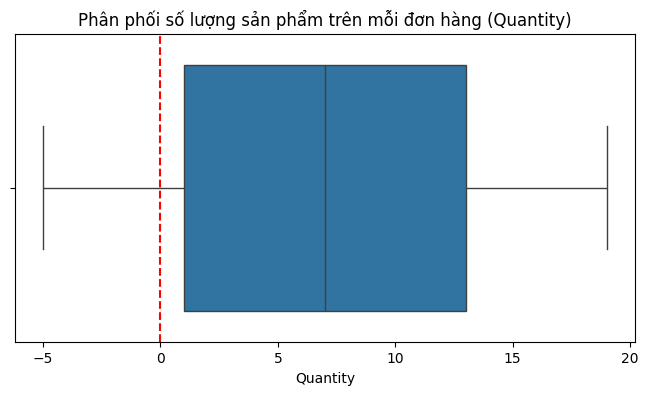

In [ ]:
# Vẽ biểu đồ phân phối của Quantity để trực quan hóa lỗi
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Quantity'])
plt.title('Phân phối số lượng sản phẩm trên mỗi đơn hàng (Quantity)')
plt.axvline(x=0, color='r', linestyle='--')
plt.show()

In [ ]:
negative_qty = len(df[df['Quantity'] <= 0])
print(f"Số lượng đơn hàng có Quantity <= 0 (Bị hủy/hoàn trả): {negative_qty} dòng")
print("=> Quyết định: Sẽ filter loại bỏ các dòng Quantity <= 0 trong Pipeline.")

Số lượng đơn hàng có Quantity <= 0 (Bị hủy/hoàn trả): 2451 dòng
=> Quyết định: Sẽ filter loại bỏ các dòng Quantity <= 0 trong Pipeline.


 ## 4. Phân tích Sơ bộ Về Doanh thu (Sales)

In [ ]:
# Thử tính doanh thu sau khi drop lỗi
df_clean = df.dropna(subset=['CustomerID'])
df_clean = df_clean[df_clean['Quantity'] > 0]
df_clean['Sales'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("Top 5 khách hàng chi tiêu nhiều nhất (Historical LTV sơ bộ):")
print(df_clean.groupby('CustomerID')['Sales'].sum().sort_values(ascending=False).head())

Top 5 khách hàng chi tiêu nhiều nhất (Historical LTV sơ bộ):
CustomerID
13047.0    368934.693520
14688.0    363660.754713
18074.0    357103.063391
17850.0    337010.559126
15311.0    333562.550915
Name: Sales, dtype: float64


 ### Kết luận từ EDA:
 1. Tập dữ liệu có khoảng ~16% missing values ở cột `CustomerID`. Cần drop.
 2. Cột `Quantity` có chứa giá trị âm, đại diện cho các đơn hàng bị hủy. Cần drop.

 -> Đã có đủ thông tin và logic để viết script tự động hóa `src/rfm_churn_pipeline.py`.